<a href="https://colab.research.google.com/github/tusharsonwane27/30-Days-Of-JavaScript/blob/master/data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('products_asos.csv', on_bad_lines = 'skip')

df['price'] = pd.to_numeric(df['price'], errors = 'coerce') #coerce will make the non numeric value to na
df = df.dropna(subset=['price'])

print(f"Data loaded: {len(df)} rows")
df.head()

Data loaded: 18378 rows


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [15]:
# get brand columns form existing description columns

df['description'] = df['description'].astype(str)

def get_brand(text):
  if 'by ' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "Unknown"
  return "Unknown"

df['brand_raw'] = df['description'].apply(get_brand)

In [11]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,brand_raw
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [16]:
brand_map = {

             'New': 'New Look',
             'River': 'River Island',
             'Miss': 'Miss Selfridge',
             'TopshopWelcome': 'Topshop'
}

df['Brand'] = df['brand_raw'].map(brand_map).fillna(df['brand_raw'])

brand_count = df['Brand'].value_counts()
valid_brands = brand_count[brand_count >= 5].index
df_clean = df[df['Brand'].isin(valid_brands)].copy()

print(df_clean['Brand'].value_counts().head(5))
#

Brand
ASOS              4844
Topshop           1017
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


In [17]:
# 1. Function to analyze the stockouts
def calculate_phantom_revenue(size_str):
  if not isinstance(size_str, str):
    return 0, 0.0

# Split "UK 6, UK 8 - out of stock" into list
  sizes = size_str.split(',')
  total_sizes = len(sizes)

  #count how many items are out of stock
  out_of_stock_count = size_str.count('Out of stock')

  # Calculat rate (0.0 to 1.0)
  rate = out_of_stock_count / total_sizes if total_sizes > 0 else 0.0

  return out_of_stock_count, rate
metrics = df_clean['size'].apply(lambda x: calculate_phantom_revenue(x))


df_clean['Stockout_Count'] = [x[0] for x in metrics]
df_clean['Stockout_Rate'] = [x[1] for x in metrics]

df_clean['Lost_Revenue'] = df_clean['price']*df_clean['Stockout_Count']

cols = ['Brand','name', 'price', 'Stockout_Count', 'Lost_Revenue']
print(df_clean.sort_values(by='Lost_Revenue', ascending=False).head(5)[cols])

                  Brand                                               name  \
2941            Barbour               Barbour Beadnell wax jacket in black   
2679   BarbourExclusive  Barbour x ASOS exclusive Stephanie wax parka i...   
21948           Topshop  Topshop premium real leather collared zip thro...   
2715               ASOS  ASOS DESIGN premium real leather trench coat i...   
15584              ASOS  ASOS EDITION geo embellished fringe plunge mid...   

       price  Stockout_Count  Lost_Revenue  
2941   219.0               9        1971.0  
2679   279.0               7        1953.0  
21948  260.0               7        1820.0  
2715   220.0               7        1540.0  
15584  250.0               6        1500.0  


/tmp/ipykernel_6422/1216786247.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


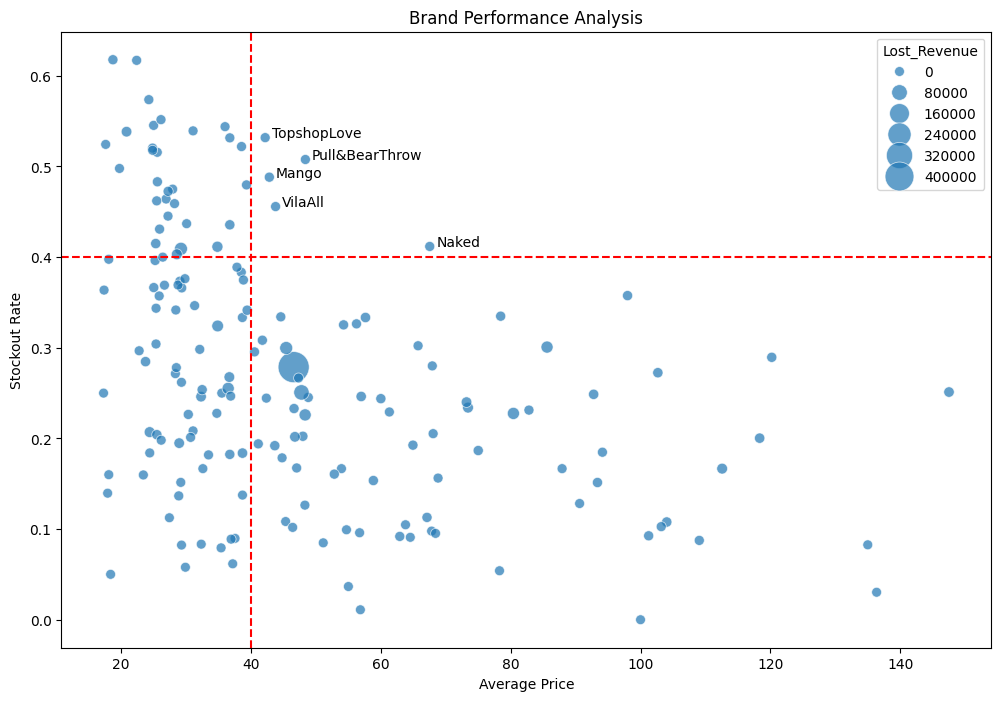

In [33]:
brand_statergy = df_clean.groupby('Brand').agg({
    'price': 'mean',
    'Stockout_Rate': 'mean',
    'Lost_Revenue': 'sum',
    'name': 'count'
}).reset_index()

brand_statergy= brand_statergy[brand_statergy['name']>10]

plt.figure(figsize=(12,8))
sns.scatterplot(
     data=brand_statergy,
     x='price',
     y='Stockout_Rate',
     size ='Lost_Revenue',
     sizes=(50,500),
     alpha=0.7,
     palette = 'viridis'
)

winners = brand_statergy[
    (brand_statergy['price']>40) & (brand_statergy['Stockout_Rate']>0.4)
]

for i in range(len(winners)):
  plt.text(
      winners.iloc[i]['price']+1,
      winners.iloc[i]['Stockout_Rate'],
      winners.iloc[i]['Brand']
      )

plt.title('Brand Performance Analysis')
plt.xlabel('Average Price')
plt.ylabel('Stockout Rate')
plt.axvline(x=40, color='red', linestyle='--')
plt.axhline(y=0.4, color='red', linestyle='--')


plt.show()